**Game Genre Recommender System ด้วย Graph** <br>แนวคิดคือ ผู้ใช้ชอบแนวเกมอะไร → หา User คนอื่นที่ชอบแนวเกมคล้ายกัน → ดูว่าคนเหล่านั้นชอบแนวเกมอะไรอีก → แนะนำแนวเกมนั้นกลับมา

ตัวอย่างสถานการณ์  มีผู้ใช้ 10 คน <br>

```
"Alice",
"Bob",
"Charlie",
"David",
"Eve",
"Frank",
"Grace",
"Heidi",
"Ivan",
"Judy",
```

และมีแนวเกม

```
"Action",
"RPG",
"FPS",
"MOBA",
"Strategy",
"Simulation",
"Puzzle",
"Racing",
"Sports",
"Horror",
```

สมมติข้อมูลความชอบคือ

Alice   → Action
Alice   → RPG

Bob     → Action
Bob     → RPG
Bob     → FPS

Charlie → Action
Charlie → MOBA

David   → FPS
David   → Strategy

Eve     → Strategy
Eve     → Simulation
Eve     → Puzzle

Frank   → MOBA
Frank   → Action
Frank   → Racing

Grace   → Racing
Grace   → Sports

Heidi   → Horror
Heidi   → Action
Heidi   → RPG

Ivan    → Horror
Ivan    → Puzzle

Judy    → Sports
Judy    → Simulation

เราจะสังเกตได้ว่า

Alice และ Bob ชอบแนวเกม Action และ RPG เหมือนกัน

แต่ Bob ยังชอบแนวเกม FPS

ดังนั้นระบบสามารถคิดง่าย ๆ ว่า

ถ้า Alice กับ Bob มีความชอบคล้ายกัน
และ Bob ชอบ FPS แต่ Alice ยังไม่ได้เลือก FPS
ระบบอาจแนะนำแนวเกม FPS ให้ Alice

นี่คือ Recommender System แบบ Graph อย่างง่ายค่ะ

การออกแบบ Graph

เราแบ่ง Node เป็น 2 ประเภท

User
Genre

Relationship คือ

LIKES

ดังนั้น

(User)-[:LIKES]->(Genre)

เช่น

(Alice)-[:LIKES]->(Action)

หรือถ้าเป็น Python NetworkX

G.add_edge("Alice", "Action")

**สร้างด้วย Python บน Google Colab**

In [ ]:
!pip -q install networkx

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

In [ ]:
G = nx.Graph()

In [ ]:
#add user (10 คน)
users = [
    "Alice",
    "Bob",
    "Charlie",
    "David",
    "Eve",
    "Frank",
    "Grace",
    "Heidi",
    "Ivan",
    "Judy"
]

for user in users:
    G.add_node(
        user,
        node_type="user"
    )

In [ ]:
#add genres (10 แนวเกม)
genres = [
    "Action",
    "RPG",
    "FPS",
    "MOBA",
    "Strategy",
    "Simulation",
    "Puzzle",
    "Racing",
    "Sports",
    "Horror"
]

for genre in genres:
    G.add_node(
        genre,
        node_type="genre"
    )

In [ ]:
#add relationship (ทุกคนชอบอย่างน้อย 2 แนวเกม)
likes = [
    ("Alice", "Action"),
    ("Alice", "RPG"),

    ("Bob", "Action"),
    ("Bob", "RPG"),
    ("Bob", "FPS"),

    ("Charlie", "Action"),
    ("Charlie", "MOBA"),

    ("David", "FPS"),
    ("David", "Strategy"),

    ("Eve", "Strategy"),
    ("Eve", "Simulation"),
    ("Eve", "Puzzle"),

    ("Frank", "MOBA"),
    ("Frank", "Action"),
    ("Frank", "Racing"),

    ("Grace", "Racing"),
    ("Grace", "Sports"),

    ("Heidi", "Horror"),
    ("Heidi", "Action"),
    ("Heidi", "RPG"),

    ("Ivan", "Horror"),
    ("Ivan", "Puzzle"),

    ("Judy", "Sports"),
    ("Judy", "Simulation")
]

เพิ่มเข้า Graph

In [ ]:
G.add_edges_from(likes)

วาด Graph

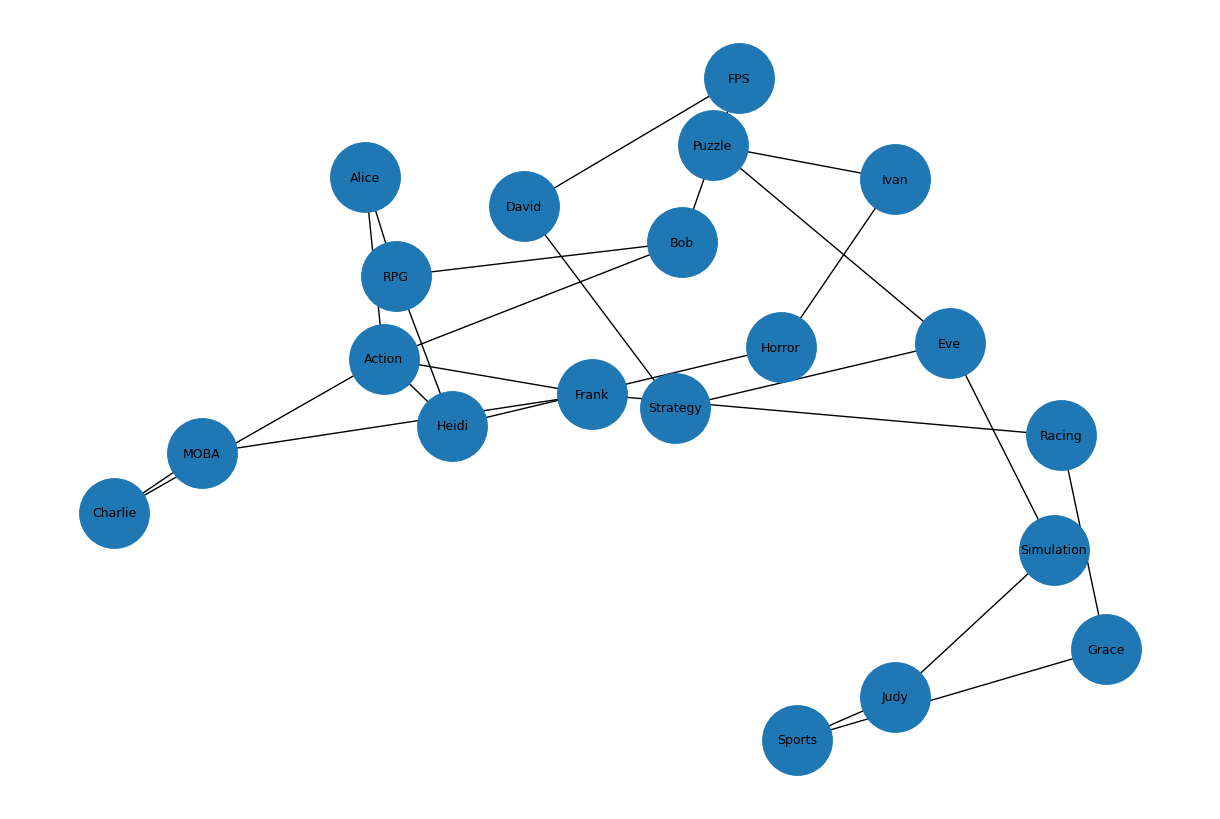

In [ ]:
plt.figure(figsize=(12, 8))

pos = nx.spring_layout(
    G,
    k=0.8,
    seed=42
)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2500,
    font_size=9
)

plt.show()

คำถามแรก <br>
1.ถามว่า Alice ชอบเล่นเกมแนวไหนบ้าง?

In [ ]:
alice_genres = list(
    G.neighbors("Alice")
)

print(alice_genres)

['Action', 'RPG']


ตรงนี้อธิบายได้ว่า Neighbor ของ Alice คือ Node ที่เชื่อมกับ Alice

คำถามที่ 2. หา User ที่ชอบแนวเกมเหมือน Bob


Bob ชอบ Action, RPG และ FPS


เราสามารถหาได้ว่าใครชอบแนวเกมเหล่านี้เหมือนกันบ้าง

In [ ]:
for genre in G.neighbors("Bob"):

    print("Genre:", genre)

    for user in G.neighbors(genre):

        if user != "Bob":
            print("   Similar user:", user)

Genre: Action
   Similar user: Alice
   Similar user: Charlie
   Similar user: Frank
   Similar user: Heidi
Genre: RPG
   Similar user: Alice
   Similar user: Heidi
Genre: FPS
   Similar user: David


**สร้าง Recommendation แบบง่าย**

```
แนวคิดคือ

Alice
 ↓
แนวเกมที่ Alice ชอบ
 ↓
User ที่ชอบแนวเกมเดียวกัน
 ↓
แนวเกมอื่นที่ User เหล่านั้นชอบ
 ↓
แนะนำให้ Alice
```



In [ ]:
from collections import Counter


target_user = "Bob"

recommendations = Counter()


# แนวเกมที่ Alice ชอบแล้ว
liked_genres = set(
    G.neighbors(target_user)
)


# ดูแนวเกมแต่ละแนวที่ Alice ชอบ
for genre in liked_genres:

    # หา User ที่ชอบแนวเกมเดียวกัน
    for similar_user in G.neighbors(genre):

        if similar_user == target_user:
            continue

        # ดูว่า User คนนั้นชอบแนวเกมอะไรอีก
        for other_genre in G.neighbors(similar_user):

            # Alice ยังไม่เคยชอบแนวนี้
            if other_genre not in liked_genres:

                recommendations[other_genre] += 1


print(recommendations)

Counter({'MOBA': 2, 'Horror': 2, 'Strategy': 1, 'Racing': 1})


MOBA และ Horror ถูกพบจาก User ที่มีความชอบแนวเกมร่วมกับ Bob มากที่สุด (2 ครั้ง) จึงเป็นแนวเกมที่ระบบจะแนะนำเป็นอันดับแรก

In [ ]:
# นำไปสร้างเป็นฟังก์ชัน

In [ ]:
from collections import Counter


def recommend_genres(G, target_user):

    recommendations = Counter()

    liked_genres = set(
        G.neighbors(target_user)
    )

    for genre in liked_genres:

        for similar_user in G.neighbors(genre):

            if similar_user == target_user:
                continue

            for other_genre in G.neighbors(similar_user):

                if other_genre not in liked_genres:

                    recommendations[other_genre] += 1

    return recommendations.most_common()

In [ ]:
#เรียกใช้งาน
result = recommend_genres(G, "Alice")
print(result)

[('FPS', 2), ('MOBA', 2), ('Horror', 2), ('Racing', 1)]


In [ ]:
#เรียกใช้งาน
result = recommend_genres(G, "Charlie")
print(result)

[('RPG', 3), ('Racing', 2), ('FPS', 1), ('Horror', 1)]


In [ ]:
#เรียกใช้งาน
result = recommend_genres(G, "Bob")
print(result)

[('MOBA', 2), ('Horror', 2), ('Strategy', 1), ('Racing', 1)]


In [ ]:
alice_genres = list(
    G.neighbors("Alice")
)

print(alice_genres)

['Action', 'RPG']


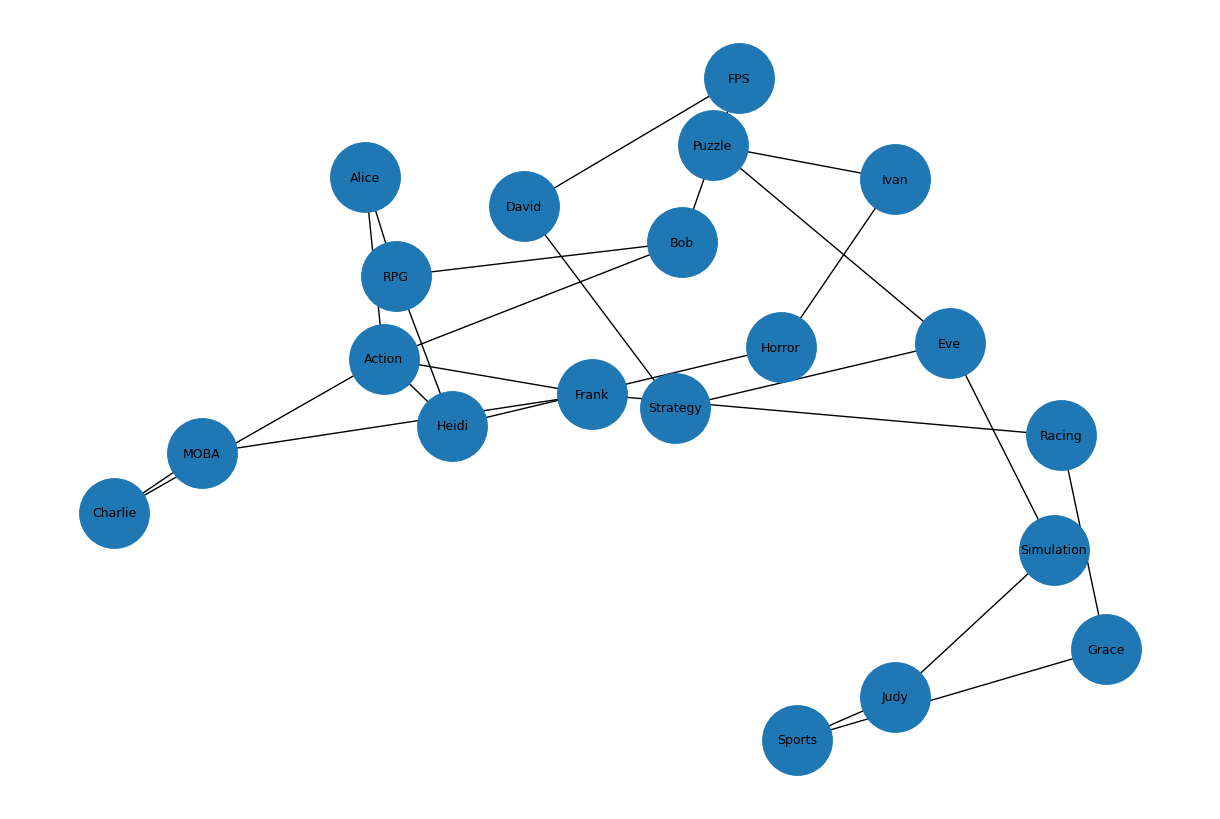

Recommendations for Bob
MOBA Score = 2
Horror Score = 2
Strategy Score = 1
Racing Score = 1


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

from collections import Counter


# ==================================
# 1. Create Graph
# ==================================

G = nx.Graph()


# ==================================
# 2. Add Users (10 คน)
# ==================================

users = [
    "Alice",
    "Bob",
    "Charlie",
    "David",
    "Eve",
    "Frank",
    "Grace",
    "Heidi",
    "Ivan",
    "Judy"
]

for user in users:

    G.add_node(
        user,
        node_type="user"
    )


# ==================================
# 3. Add Genres (10 แนวเกม)
# ==================================

genres = [
    "Action",
    "RPG",
    "FPS",
    "MOBA",
    "Strategy",
    "Simulation",
    "Puzzle",
    "Racing",
    "Sports",
    "Horror"
]

for genre in genres:

    G.add_node(
        genre,
        node_type="genre"
    )


# ==================================
# 4. User-Genre Relationships (ทุกคนชอบอย่างน้อย 2 แนวเกม)
# ==================================

likes = [

    ("Alice", "Action"),
    ("Alice", "RPG"),

    ("Bob", "Action"),
    ("Bob", "RPG"),
    ("Bob", "FPS"),

    ("Charlie", "Action"),
    ("Charlie", "MOBA"),

    ("David", "FPS"),
    ("David", "Strategy"),

    ("Eve", "Strategy"),
    ("Eve", "Simulation"),
    ("Eve", "Puzzle"),

    ("Frank", "MOBA"),
    ("Frank", "Action"),
    ("Frank", "Racing"),

    ("Grace", "Racing"),
    ("Grace", "Sports"),

    ("Heidi", "Horror"),
    ("Heidi", "Action"),
    ("Heidi", "RPG"),

    ("Ivan", "Horror"),
    ("Ivan", "Puzzle"),

    ("Judy", "Sports"),
    ("Judy", "Simulation")

]


G.add_edges_from(likes)


# ==================================
# 5. Draw Graph
# ==================================

plt.figure(
    figsize=(12, 8)
)


pos = nx.spring_layout(
    G,
    k=0.8,
    seed=42
)


nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2500,
    font_size=9
)


plt.show()


# ==================================
# 6. Recommendation Function
# ==================================

def recommend_genres(
    G,
    target_user
):

    recommendations = Counter()

    liked_genres = set(
        G.neighbors(
            target_user
        )
    )

    for genre in liked_genres:

        for similar_user in G.neighbors(genre):

            if similar_user == target_user:
                continue

            for other_genre in G.neighbors(
                similar_user
            ):

                if other_genre not in liked_genres:

                    recommendations[
                        other_genre
                    ] += 1

    return recommendations.most_common()


# ==================================
# 7. Recommend for Bob
# ==================================

target_user = "Bob"

result = recommend_genres(
    G,
    target_user
)


print(
    "Recommendations for",
    target_user
)


for genre, score in result:

    print(
        genre,
        "Score =",
        score
    )

Recommender System แบบ Graph ไม่ได้มองเพียงว่า “เกมแนวไหนเป็นที่นิยมทั่วไป” แต่ดูว่า “ผู้ใช้คนนี้เชื่อมโยงกับผู้ใช้คนอื่นและแนวเกมอื่นอย่างไร”